<a href="https://colab.research.google.com/github/pariiii-khandal/EDA_PROJECT/blob/main/25BDS0197_Lab4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Summary Statistics for the Dataset ---
                       count        mean         std      min        25%  \
fixed acidity         1143.0    8.311111    1.747595  4.60000    7.10000   
volatile acidity      1143.0    0.531339    0.179633  0.12000    0.39250   
citric acid           1143.0    0.268364    0.196686  0.00000    0.09000   
residual sugar        1143.0    2.532152    1.355917  0.90000    1.90000   
chlorides             1143.0    0.086933    0.047267  0.01200    0.07000   
free sulfur dioxide   1143.0   15.615486   10.250486  1.00000    7.00000   
total sulfur dioxide  1143.0   45.914698   32.782130  6.00000   21.00000   
density               1143.0    0.996730    0.001925  0.99007    0.99557   
pH                    1143.0    3.311015    0.156664  2.74000    3.20500   
sulphates             1143.0    0.657708    0.170399  0.33000    0.55000   
alcohol               1143.0   10.442111    1.082196  8.40000    9.50000   
quality               1143.0    5.657043    0

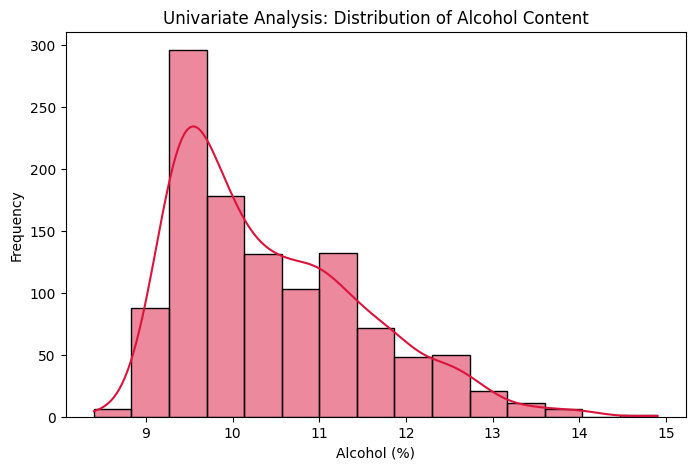

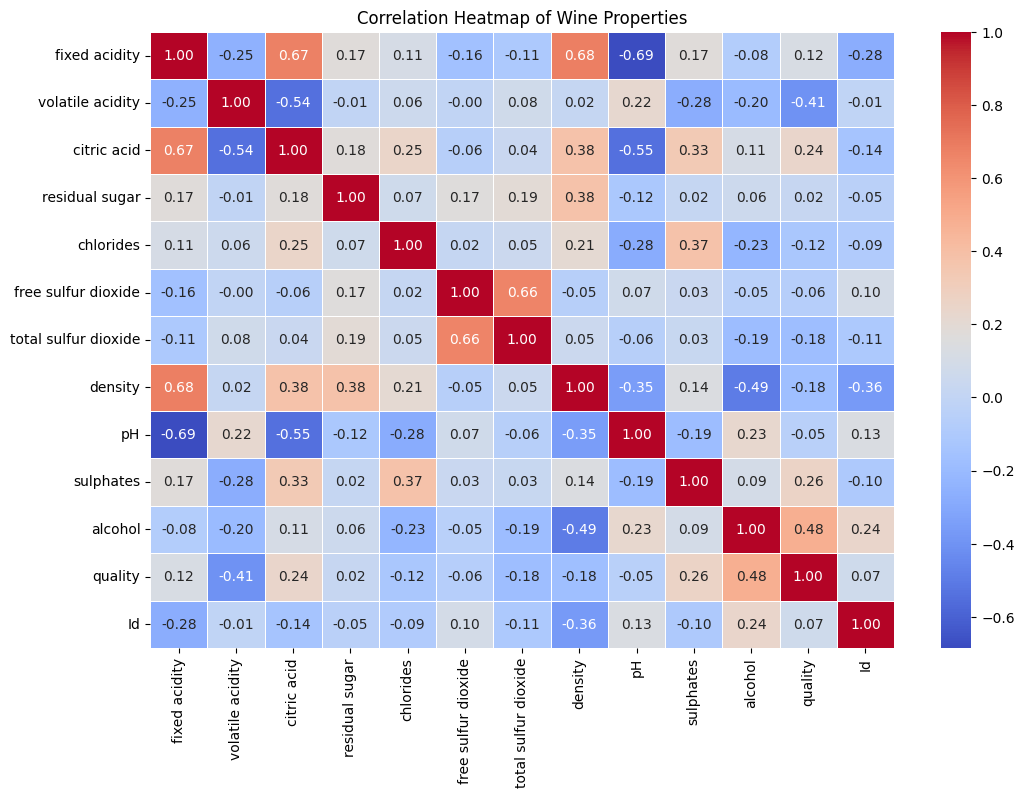

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. Load your wine quality dataset
# Replace 'WineQT.csv' with your actual file path if it differs
df = pd.read_csv("WineQT.csv")

# 2. Complete Univariate Summary (Central Tendency & Dispersion)
# This generates the count, mean, standard deviation, min, 25%, 50% (median), 75%, and max
print("--- Summary Statistics for the Dataset ---")
print(df.describe().T)

# To find specific target measures like the Mode for a single column (e.g., alcohol)
alcohol_mode = df['alcohol'].mode()[0]
print(f"\nMode of Alcohol: {alcohol_mode}")

# 3. Create a Univariate Visualization (Histogram & KDE)
# This helps visually interpret the mean spread and standard deviation skewness
plt.figure(figsize=(8, 5))
sns.histplot(df['alcohol'], kde=True, color='crimson', bins=15)
plt.title('Univariate Analysis: Distribution of Alcohol Content')
plt.xlabel('Alcohol (%)')
plt.ylabel('Frequency')
plt.show()

# 4. Introducing Correlation (Bivariate/Multivariate relationship matrix)
# Calculate the numerical correlation values between -1 and 1
correlation_matrix = df.corr()

# Visualize the correlation matrix with a Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Wine Properties')
plt.show()


In [7]:
import pandas as pd
df = pd.read_csv("https://raw.githubusercontent.com/salemprakash/EDA/main/Data/data.csv")
print(df.head(3))
print(df.tail(3))


   symboling normalized-losses         make fuel-type aspiration num-of-doors  \
0          3                 ?  alfa-romero       gas        std          two   
1          3                 ?  alfa-romero       gas        std          two   
2          1                 ?  alfa-romero       gas        std          two   

    body-style drive-wheels engine-location  wheel-base  ...  engine-size  \
0  convertible          rwd           front        88.6  ...          130   
1  convertible          rwd           front        88.6  ...          130   
2    hatchback          rwd           front        94.5  ...          152   

   fuel-system  bore  stroke compression-ratio horsepower  peak-rpm city-mpg  \
0         mpfi  3.47    2.68               9.0        111      5000       21   
1         mpfi  3.47    2.68               9.0        111      5000       21   
2         mpfi  2.68    3.47               9.0        154      5000       19   

  highway-mpg  price  
0          27  13495  

In [8]:
print(df.dtypes)


symboling              int64
normalized-losses     object
make                  object
fuel-type             object
aspiration            object
num-of-doors          object
body-style            object
drive-wheels          object
engine-location       object
wheel-base           float64
length               float64
width                float64
height               float64
curb-weight            int64
engine-type           object
num-of-cylinders      object
engine-size            int64
fuel-system           object
bore                  object
stroke                object
compression-ratio    float64
horsepower            object
peak-rpm              object
city-mpg               int64
highway-mpg            int64
price                 object
dtype: object


In [9]:
print("--- Descriptive Statistics ---")
print(df.describe(include='all'))  # include='all' covers both numeric and object columns

price_valid = df['price'].loc[df['price'] != '?']
price_mean = price_valid.astype(int).mean()

df['price'] = df['price'].replace('?', price_mean).astype(int)
hp_valid = df['horsepower'].loc[df['horsepower'] != '?']
hp_mean = hp_valid.astype(int).mean()

df['horsepower'] = df['horsepower'].replace('?', hp_mean).astype(int)
nl_numeric = pd.to_numeric(df['normalized-losses'], errors='coerce')
nl_mean = nl_numeric.mean()

df['normalized-losses'] = df['normalized-losses'].replace('?', nl_mean).astype(int)

print("\n--- Cleaned Normalized Losses Head ---")
print(df['normalized-losses'].head())


--- Descriptive Statistics ---
         symboling normalized-losses    make fuel-type aspiration  \
count   205.000000               205     205       205        205   
unique         NaN                52      22         2          2   
top            NaN                 ?  toyota       gas        std   
freq           NaN                41      32       185        168   
mean      0.834146               NaN     NaN       NaN        NaN   
std       1.245307               NaN     NaN       NaN        NaN   
min      -2.000000               NaN     NaN       NaN        NaN   
25%       0.000000               NaN     NaN       NaN        NaN   
50%       1.000000               NaN     NaN       NaN        NaN   
75%       2.000000               NaN     NaN       NaN        NaN   
max       3.000000               NaN     NaN       NaN        NaN   

       num-of-doors body-style drive-wheels engine-location  wheel-base  ...  \
count           205        205          205             205 

In [10]:
mean = df["height"].mean()
median = df["height"].median()
mode = df["height"].mode()

print(f"Mean: {mean}")
print(f"Median: {median}")
print(f"Mode:\n{mode}")


Mean: 53.72487804878049
Median: 54.1
Mode:
0    50.8
Name: height, dtype: float64


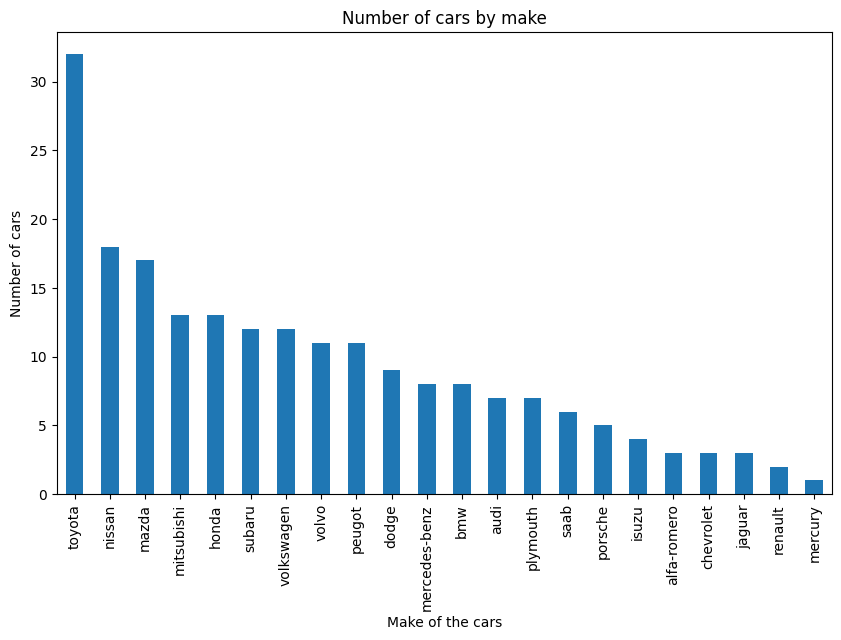

In [11]:
import matplotlib.pyplot as plt

df.make.value_counts().nlargest(30).plot(kind='bar', figsize=(10, 6))

plt.title("Number of cars by make")
plt.ylabel('Number of cars')
plt.xlabel('Make of the cars')

plt.show()


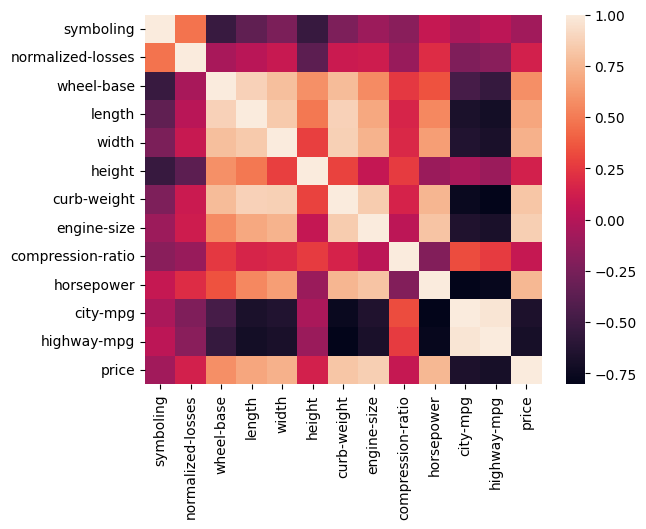

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.heatmap(correlation, xticklabels=correlation.columns, yticklabels=correlation.columns)

plt.show()


In [14]:
correlation = df.corr(method='pearson', numeric_only=True)
print(correlation)

                   symboling  normalized-losses  wheel-base    length  \
symboling           1.000000           0.465190   -0.531954 -0.357612   
normalized-losses   0.465190           1.000000   -0.056518  0.019209   
wheel-base         -0.531954          -0.056518    1.000000  0.874587   
length             -0.357612           0.019209    0.874587  1.000000   
width              -0.232919           0.084195    0.795144  0.841118   
height             -0.541038          -0.370706    0.589435  0.491029   
curb-weight        -0.227691           0.097785    0.776386  0.877728   
engine-size        -0.105790           0.110997    0.569329  0.683360   
compression-ratio  -0.178515          -0.114525    0.249786  0.158414   
horsepower          0.071380           0.203434    0.351985  0.554408   
city-mpg           -0.035823          -0.218749   -0.470414 -0.670909   
highway-mpg         0.034606          -0.178221   -0.544082 -0.704662   
price              -0.082201           0.133999    

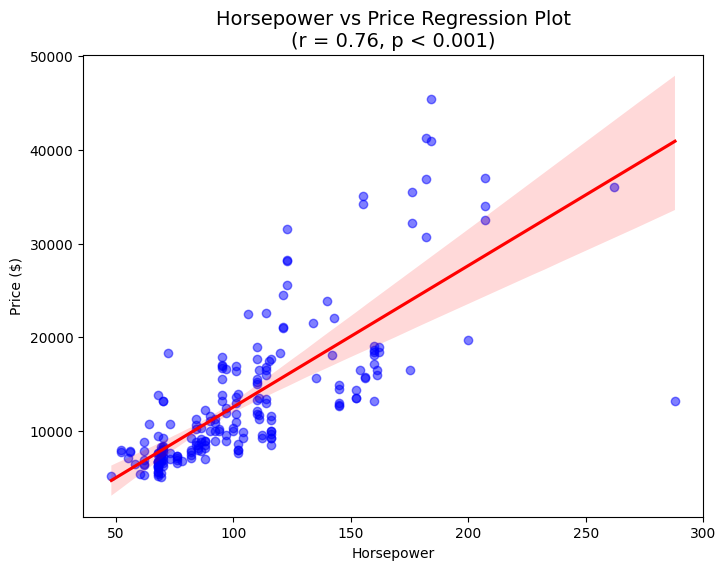

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

sns.regplot(x="horsepower", y="price", data=df,
            scatter_kws={"color": "blue", "alpha": 0.5},
            line_kws={"color": "red"})

plt.title("Horsepower vs Price Regression Plot\n(r = 0.76, p < 0.001)", fontsize=14)
plt.xlabel("Horsepower")
plt.ylabel("Price ($)")

plt.show()


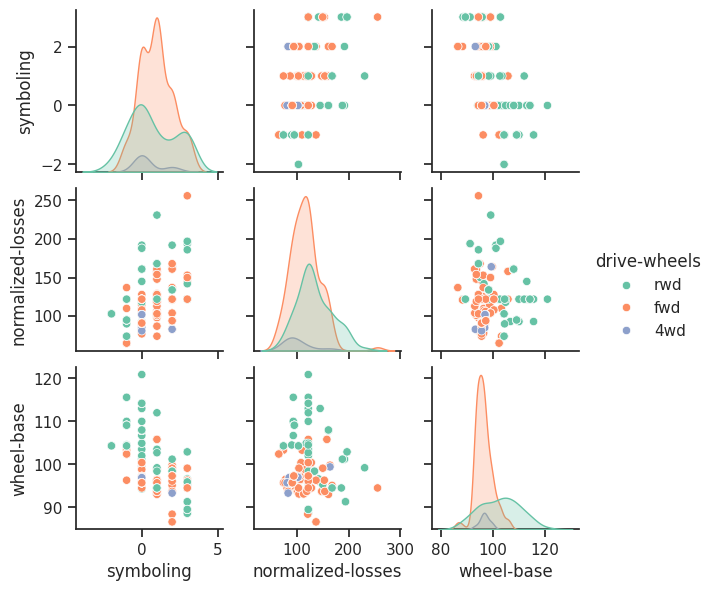

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

df['normalized-losses'] = pd.to_numeric(df['normalized-losses'], errors='coerce')
df_clean = df.dropna(subset=['symboling', 'normalized-losses', 'wheel-base', 'drive-wheels'])

sns.set_theme(style="ticks")

sns.pairplot(
    df_clean,
    vars=['symboling', 'normalized-losses', 'wheel-base'],
    hue="drive-wheels",
    height=2,
    palette="Set2",
    diag_kind="kde"
)

plt.show()
